# 🌾 Pix2Pix Training — junyanz repo
**Based on:** https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix  
**Fix:** Shell-based training → no 2hr cell timeout  
**Dataset:** patches_256 (A/B separate → merged side-by-side)


In [1]:
# from pathlib import Path

# base = Path('/kaggle/input/datasets/devanadi/pix2pix-checkpoints-ep90/pytorch-CycleGAN-and-pix2pix/checkpoints/rice_ndvi_pix2pix')
# print(f'Exists: {base.exists()}')
# print()
# for f in sorted(base.rglob('*'))[:30]:
#     print(f'  {f.relative_to(base)}')

## 🔍 Step 0 — GPU Check

In [2]:
import torch
assert torch.cuda.is_available(), 'NO GPU! Enable GPU T4x2 first.'
print(f'GPU: {torch.cuda.get_device_name(0)} x{torch.cuda.device_count()}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')


GPU: Tesla T4 x2
VRAM: 14.6 GB


## 📦 Step 1 — Clone junyanz Repo & Install

In [3]:
import os
from pathlib import Path

# Clone repo if not exists
if not Path('/kaggle/working/pytorch-CycleGAN-and-pix2pix').exists():
    os.system('git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix /kaggle/working/pytorch-CycleGAN-and-pix2pix')
    print('Repo cloned.')
else:
    print('Repo already exists.')

os.chdir('/kaggle/working/pytorch-CycleGAN-and-pix2pix')
print(f'Working dir: {os.getcwd()}')


Cloning into '/kaggle/working/pytorch-CycleGAN-and-pix2pix'...


Repo cloned.
Working dir: /kaggle/working/pytorch-CycleGAN-and-pix2pix


In [4]:
!pip install dominate visdom -q
print('Dependencies installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dependencies installed.


## 🔄 Step 2 — Prepare Dataset (A|B Side-by-Side)
> junyanz expects RGB and NDVI merged horizontally: [RGB|NDVI] = 512×256
> This cell converts your separate A/ B/ folders into this format.

In [5]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import random

# ── Paths ─────────────────────────────────────────────────────
SRC_DIR  = '/kaggle/input/datasets/devanadi/pix2pix-resize-512to256/patches_256'
DST_DIR  = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi'
MAX_TRAIN = 8000   # subset for speed
SPLITS    = ['train', 'val', 'test']

def merge_ab(img_a_bgr, img_b_gray):
    """
    Merge RGB (A) and NDVI grayscale (B) side by side.
    Output: [A|B] = 512x256 (width x height)
    junyanz reads left half as A, right half as B.
    """
    img_b_bgr = cv2.cvtColor(img_b_gray, cv2.COLOR_GRAY2BGR)
    return np.concatenate([img_a_bgr, img_b_bgr], axis=1)  # horizontal concat


for split in SPLITS:
    src_a = Path(SRC_DIR)/split/'A'
    src_b = Path(SRC_DIR)/split/'B'
    dst   = Path(DST_DIR)/split
    dst.mkdir(parents=True, exist_ok=True)

    files = sorted([f.name for f in src_a.glob('*.jpg')
                    if (src_b/f.name).exists()])

    # Limit train set
    if split == 'train' and len(files) > MAX_TRAIN:
        files = random.sample(files, MAX_TRAIN)
        print(f'Train subset: {MAX_TRAIN} pairs')

    saved = 0
    for fname in tqdm(files, desc=f'Merge {split}'):
        img_a = cv2.imread(str(src_a/fname))
        img_b = cv2.imread(str(src_b/fname), cv2.IMREAD_GRAYSCALE)
        if img_a is None or img_b is None: continue
        merged = merge_ab(img_a, img_b)
        cv2.imwrite(str(dst/fname), merged, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved += 1

    print(f'{split}: {saved:,} merged images saved -> {dst}')

print('Dataset preparation complete!')
print(f'Format: each image = 512x256 [RGB|NDVI] side-by-side')


Train subset: 8000 pairs


Merge train: 100%|██████████| 8000/8000 [02:37<00:00, 50.75it/s]


train: 8,000 merged images saved -> /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi/train


Merge val: 100%|██████████| 5280/5280 [01:42<00:00, 51.54it/s]


val: 5,280 merged images saved -> /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi/val


Merge test: 100%|██████████| 5464/5464 [01:50<00:00, 49.58it/s]

test: 5,464 merged images saved -> /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi/test
Dataset preparation complete!
Format: each image = 512x256 [RGB|NDVI] side-by-side


## 👀 Step 3 — Verify Merged Dataset

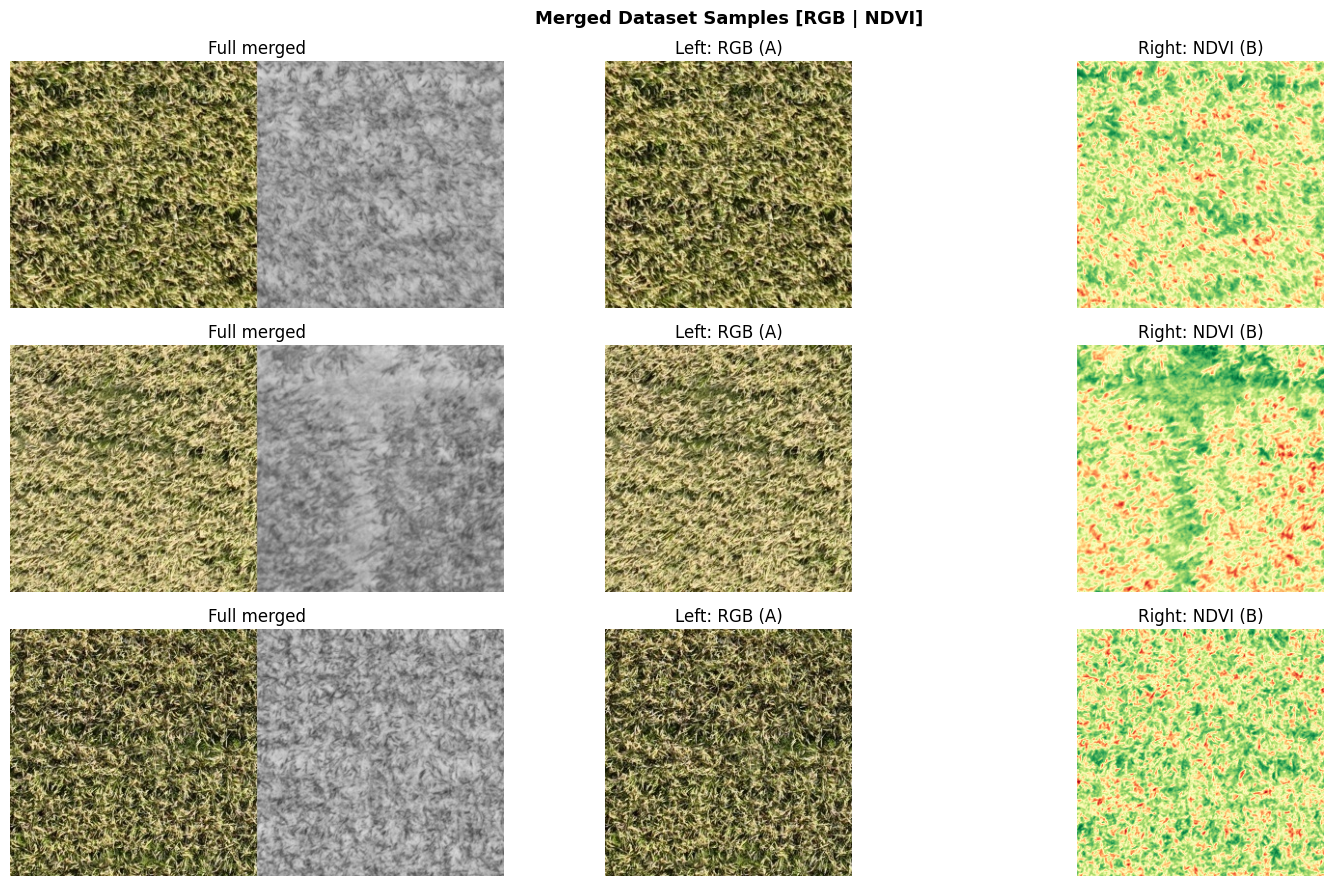

Train: 8,000 images
Val  : 5,280 images
Test : 5,464 images


In [6]:
import matplotlib.pyplot as plt
import random

train_dir = Path(DST_DIR)/'train'
files = sorted(train_dir.glob('*.jpg'))
samples = random.sample(files, min(3, len(files)))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle('Merged Dataset Samples [RGB | NDVI]', fontsize=13, fontweight='bold')

for i, f in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    mid  = w // 2
    rgb  = img[:, :mid, :]   # left half = RGB
    ndvi = img[:, mid:, :]   # right half = NDVI

    axes[i][0].imshow(img); axes[i][0].set_title('Full merged'); axes[i][0].axis('off')
    axes[i][1].imshow(rgb); axes[i][1].set_title('Left: RGB (A)'); axes[i][1].axis('off')
    axes[i][2].imshow(ndvi[:,:,0], cmap='RdYlGn'); axes[i][2].set_title('Right: NDVI (B)'); axes[i][2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/merged_sample.png', dpi=80)
plt.show()
print(f'Train: {len(list((Path(DST_DIR)/"train").glob("*.jpg"))):,} images')
print(f'Val  : {len(list((Path(DST_DIR)/"val").glob("*.jpg"))):,} images')
print(f'Test : {len(list((Path(DST_DIR)/"test").glob("*.jpg"))):,} images')


## ⚙️ Step 4 — Configure Training

In [7]:
# ── Training configuration ────────────────────────────────────
NAME         = 'rice_ndvi_pix2pix'
DATAROOT     = '/kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi'
CKPT_DIR     = f'/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/{NAME}'
N_EPOCHS     = 100   # epochs with fixed LR
N_EPOCHS_DECAY = 100 # epochs with decaying LR (total = 200)
BATCH_SIZE   = 8
NUM_GPUS     = torch.cuda.device_count()
SAVE_FREQ    = 5     # save checkpoint every N epochs
PRINT_FREQ   = 100   # print loss every N iters

Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

print(f'NAME       : {NAME}')
print(f'DATAROOT   : {DATAROOT}')
print(f'N_EPOCHS   : {N_EPOCHS} + {N_EPOCHS_DECAY} decay = {N_EPOCHS+N_EPOCHS_DECAY} total')
print(f'BATCH      : {BATCH_SIZE}')
print(f'NUM_GPUS   : {NUM_GPUS}')
print(f'SAVE_FREQ  : every {SAVE_FREQ} epochs')


NAME       : rice_ndvi_pix2pix
DATAROOT   : /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi
N_EPOCHS   : 100 + 100 decay = 200 total
BATCH      : 8
NUM_GPUS   : 2
SAVE_FREQ  : every 5 epochs


## 🚀 Step 5 — Train!
> Shell command → runs as background process  
> No 2hr cell timeout  
> Checkpoint saved every 5 epochs automatically  
> Auto-resume supported via --continue_train flag

In [8]:
import os, shutil
from pathlib import Path

# ── Cell A — Restore checkpoints ─────────────────────────────
src = Path('/kaggle/input/datasets/devanadi/pix2pix-checkpoints-ep90/pytorch-CycleGAN-and-pix2pix/checkpoints/rice_ndvi_pix2pix')
dst = Path('/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/rice_ndvi_pix2pix')
dst.mkdir(parents=True, exist_ok=True)
for f in src.glob('*'):
    shutil.copy2(str(f), str(dst/f.name))
    print(f'Restored: {f.name}')
print('Checkpoints restored! Ready to resume from epoch 91.')

# ── Cell B — Resume training ──────────────────────────────────
os.chdir('/kaggle/working/pytorch-CycleGAN-and-pix2pix')
print('Starting training from epoch 91...')
print('='*60)

!python train.py \
    --dataroot /kaggle/working/pytorch-CycleGAN-and-pix2pix/datasets/rice_ndvi \
    --name rice_ndvi_pix2pix \
    --model pix2pix \
    --direction AtoB \
    --input_nc 3 \
    --output_nc 3 \
    --n_epochs 100 \
    --n_epochs_decay 100 \
    --epoch_count 91 \
    --batch_size 8 \
    --save_epoch_freq 5 \
    --print_freq 100 \
    --no_html \
    --lambda_L1 100 \
    --load_size 256 \
    --crop_size 256 \
    --preprocess none \
    --num_threads 2 \
    --continue_train

Restored: 5_net_G.pth
Restored: 65_net_G.pth
Restored: 75_net_G.pth
Restored: 45_net_G.pth
Restored: 60_net_G.pth
Restored: 80_net_D.pth
Restored: 25_net_G.pth
Restored: 85_net_G.pth
Restored: 35_net_G.pth
Restored: 80_net_G.pth
Restored: 55_net_D.pth
Restored: 25_net_D.pth
Restored: 40_net_D.pth
Restored: 30_net_G.pth
Restored: 5_net_D.pth
Restored: latest_net_D.pth
Restored: 35_net_D.pth
Restored: loss_log.txt
Restored: 70_net_D.pth
Restored: 50_net_D.pth
Restored: train_opt.txt
Restored: 10_net_G.pth
Restored: 65_net_D.pth
Restored: 90_net_G.pth
Restored: 10_net_D.pth
Restored: 15_net_G.pth
Restored: 50_net_G.pth
Restored: 90_net_D.pth
Restored: 70_net_G.pth
Restored: 75_net_D.pth
Restored: 45_net_D.pth
Restored: 40_net_G.pth
Restored: 20_net_D.pth
Restored: 20_net_G.pth
Restored: 15_net_D.pth
Restored: 85_net_D.pth
Restored: 30_net_D.pth
Restored: latest_net_G.pth
Restored: 60_net_D.pth
Restored: 55_net_G.pth
Checkpoints restored! Ready to resume from epoch 91.
Starting training fr

## 📊 Step 6 — Monitor Checkpoints (Run Anytime)

In [9]:
from pathlib import Path

ckpt_path = Path(f'/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/{NAME}')
if not ckpt_path.exists():
    print('No checkpoints yet.')
else:
    print(f'Checkpoints in {ckpt_path}:')
    for f in sorted(ckpt_path.glob('*.pth')):
        print(f'  {f.name} ({f.stat().st_size/1024**2:.1f} MB)')

# Show latest loss log
loss_log = ckpt_path/'loss_log.txt'
if loss_log.exists():
    lines = loss_log.read_text().strip().split('\n')
    print(f'\nLast 5 loss entries:')
    for line in lines[-5:]:
        print(f'  {line}')


Checkpoints in /kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/rice_ndvi_pix2pix:
  100_net_D.pth (10.6 MB)
  100_net_G.pth (207.6 MB)
  105_net_D.pth (10.6 MB)
  105_net_G.pth (207.6 MB)
  10_net_D.pth (10.6 MB)
  10_net_G.pth (207.6 MB)
  110_net_D.pth (10.6 MB)
  110_net_G.pth (207.6 MB)
  115_net_D.pth (10.6 MB)
  115_net_G.pth (207.6 MB)
  120_net_D.pth (10.6 MB)
  120_net_G.pth (207.6 MB)
  125_net_D.pth (10.6 MB)
  125_net_G.pth (207.6 MB)
  130_net_D.pth (10.6 MB)
  130_net_G.pth (207.6 MB)
  135_net_D.pth (10.6 MB)
  135_net_G.pth (207.6 MB)
  140_net_D.pth (10.6 MB)
  140_net_G.pth (207.6 MB)
  145_net_D.pth (10.6 MB)
  145_net_G.pth (207.6 MB)
  150_net_D.pth (10.6 MB)
  150_net_G.pth (207.6 MB)
  155_net_D.pth (10.6 MB)
  155_net_G.pth (207.6 MB)
  15_net_D.pth (10.6 MB)
  15_net_G.pth (207.6 MB)
  160_net_D.pth (10.6 MB)
  160_net_G.pth (207.6 MB)
  165_net_D.pth (10.6 MB)
  165_net_G.pth (207.6 MB)
  170_net_D.pth (10.6 MB)
  170_net_G.pth (207.6 MB)
  175_net_D.

## 🔄 Step 7 — Resume Training (Next Session)
> Run Steps 0-4 first → then run this cell

In [10]:
# Check last completed epoch
import re
from pathlib import Path

ckpt_path = Path(f'/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/{NAME}')
epoch_ckpts = sorted(ckpt_path.glob('[0-9]*_net_G.pth'))

if epoch_ckpts:
    last_epochs = [int(re.search(r'(\d+)_net_G', f.name).group(1)) for f in epoch_ckpts]
    last_ep = max(last_epochs)
    print(f'Last saved epoch: {last_ep}')
    print(f'Resume from epoch: {last_ep + 1}')
    print(f'Total target: {N_EPOCHS + N_EPOCHS_DECAY}')
    print(f'Remaining: {N_EPOCHS + N_EPOCHS_DECAY - last_ep} epochs')
else:
    print('No epoch checkpoints found. Will start fresh.')

print('\nRun Step 5 cell again → it will auto-detect and resume.')


Last saved epoch: 200
Resume from epoch: 201
Total target: 200
Remaining: 0 epochs

Run Step 5 cell again → it will auto-detect and resume.


## 📈 Step 8 — Plot Loss Curves (Run Anytime)

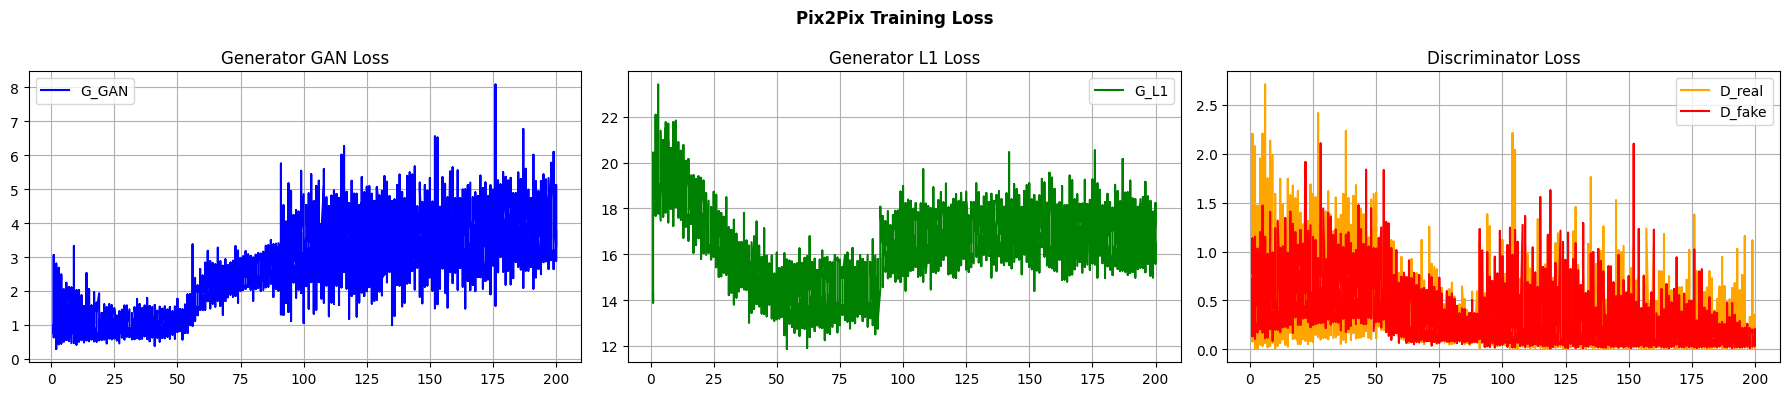

Epochs logged: 1 to 200


In [11]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

loss_log = Path(f'/kaggle/working/pytorch-CycleGAN-and-pix2pix/checkpoints/{NAME}/loss_log.txt')
if not loss_log.exists():
    print('No loss log yet. Run training first.')
else:
    epochs=[]; g_gan=[]; g_l1=[]; d_real=[]; d_fake=[]
    for line in loss_log.read_text().strip().split('\n'):
        try:
            ep  = int(re.search(r'epoch: (\d+)', line).group(1))
            gg  = float(re.search(r'G_GAN: ([\d.]+)', line).group(1))
            gl  = float(re.search(r'G_L1: ([\d.]+)', line).group(1))
            dr  = float(re.search(r'D_real: ([\d.]+)', line).group(1))
            df  = float(re.search(r'D_fake: ([\d.]+)', line).group(1))
            epochs.append(ep); g_gan.append(gg); g_l1.append(gl)
            d_real.append(dr); d_fake.append(df)
        except: continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle('Pix2Pix Training Loss', fontweight='bold')
    axes[0].plot(epochs, g_gan,  color='blue',   label='G_GAN')
    axes[0].set_title('Generator GAN Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, g_l1,   color='green',  label='G_L1')
    axes[1].set_title('Generator L1 Loss'); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(epochs, d_real, color='orange', label='D_real')
    axes[2].plot(epochs, d_fake, color='red',    label='D_fake')
    axes[2].set_title('Discriminator Loss'); axes[2].legend(); axes[2].grid(True)
    plt.tight_layout()
    plt.savefig('/kaggle/working/loss_curves.png', dpi=100)
    plt.show()
    print(f'Epochs logged: {min(epochs)} to {max(epochs)}')
